In [32]:
import scanpy as sc
import matplotlib.pyplot as plt
import omicverse as ov
import numpy as np
import pandas as pd

In [2]:
ov.style(font_path='Arial')

🔬 Starting plot initialization...
Failed to download Arial font: HTTPSConnectionPool(host='github.com', port=443): Max retries exceeded with url: /kavin808/arial.ttf/raw/refs/heads/master/arial.ttf (Caused by NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x7f4f5c459db0>: Failed to establish a new connection: [Errno 111] Connection refused'))
Continuing with default font settings...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA GeForce RTX 3060
      Memory: 12.0 GB | Compute: 8.6

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



In [3]:
adata = sc.read_h5ad('integrate_h5ad/islet_beta_PanNET_intergtated.h5ad')

In [4]:
donor_idx = adata.obs['batch'].value_counts()  
donor_keep = donor_idx[donor_idx > 200].index.to_list()
adata_sub = adata[adata.obs['batch'].isin(donor_keep)].copy()

In [5]:
adata_sub.X.max()

158798.0

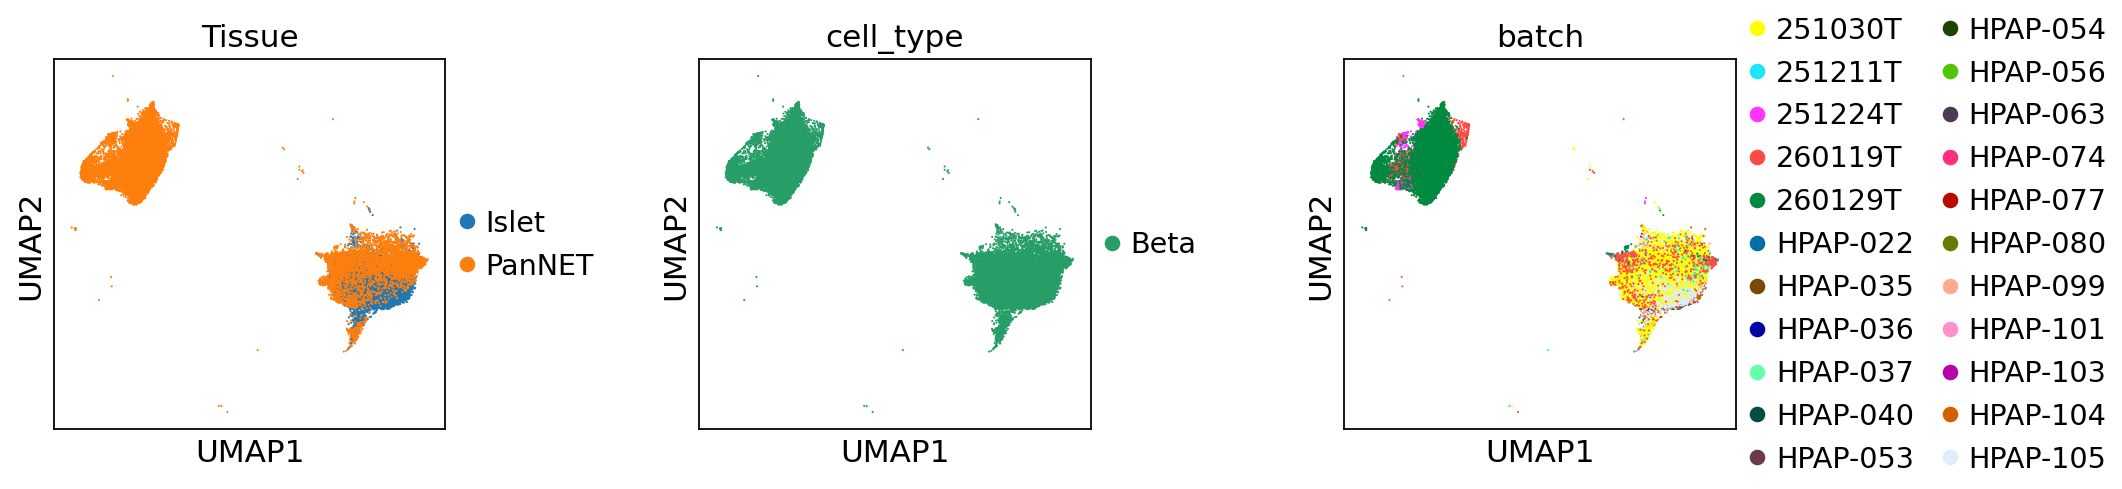

In [6]:
with plt.rc_context({'figure.figsize': (3, 3)}):
    sc.pl.umap(adata_sub,color=['Tissue','cell_type','batch'],wspace=0.5)

In [7]:
adata_sub.write_h5ad('integrate_h5ad/islet_beta_PanNET_subset_intergtated.h5ad',compression='gzip')

In [8]:
adata_sub.layers['counts'] = adata_sub.X.copy()

In [9]:
cnmf_obj = ov.single.cNMF(
    adata_sub,components=np.arange(5,15), n_iter=20, 
    seed=14, num_highvar_genes=4000,
    output_dir='cNMF', name='PanNET_cNMF',use_gpu=True
)

In [10]:
cnmf_obj.factorize(worker_i=0, total_workers=1)

🚀 Running NMF on GPU (device 0)
Running 200 factorization iterations for worker 0...


100%|██████████| 200/200 [06:03<00:00,  1.82s/it]

✓ Worker 0 completed 200 iterations. Total in memory: 200


In [11]:
cnmf_obj.combine(skip_missing_files=True)
cnmf_obj.save('cNMF/cnmf_obj.pkl')

Combining factorizations for k=5.
  Found all 20 iterations for k=5
Combining factorizations for k=6.
  Found all 20 iterations for k=6
Combining factorizations for k=7.
  Found all 20 iterations for k=7
Combining factorizations for k=8.
  Found all 20 iterations for k=8
Combining factorizations for k=9.
  Found all 20 iterations for k=9
Combining factorizations for k=10.
  Found all 20 iterations for k=10
Combining factorizations for k=11.
  Found all 20 iterations for k=11
Combining factorizations for k=12.
  Found all 20 iterations for k=12
Combining factorizations for k=13.
  Found all 20 iterations for k=13
Combining factorizations for k=14.
  Found all 20 iterations for k=14
✓ cNMF object saved to: cNMF/cnmf_obj.pkl
  - 200 factorization iterations
  - 10 merged spectra (K values)
  - 0 consensus results


In [12]:
sil_data = cnmf_obj.calculate_silhouette_k(k=7, density_threshold=2.0)

Calculating silhouette scores for K selection...


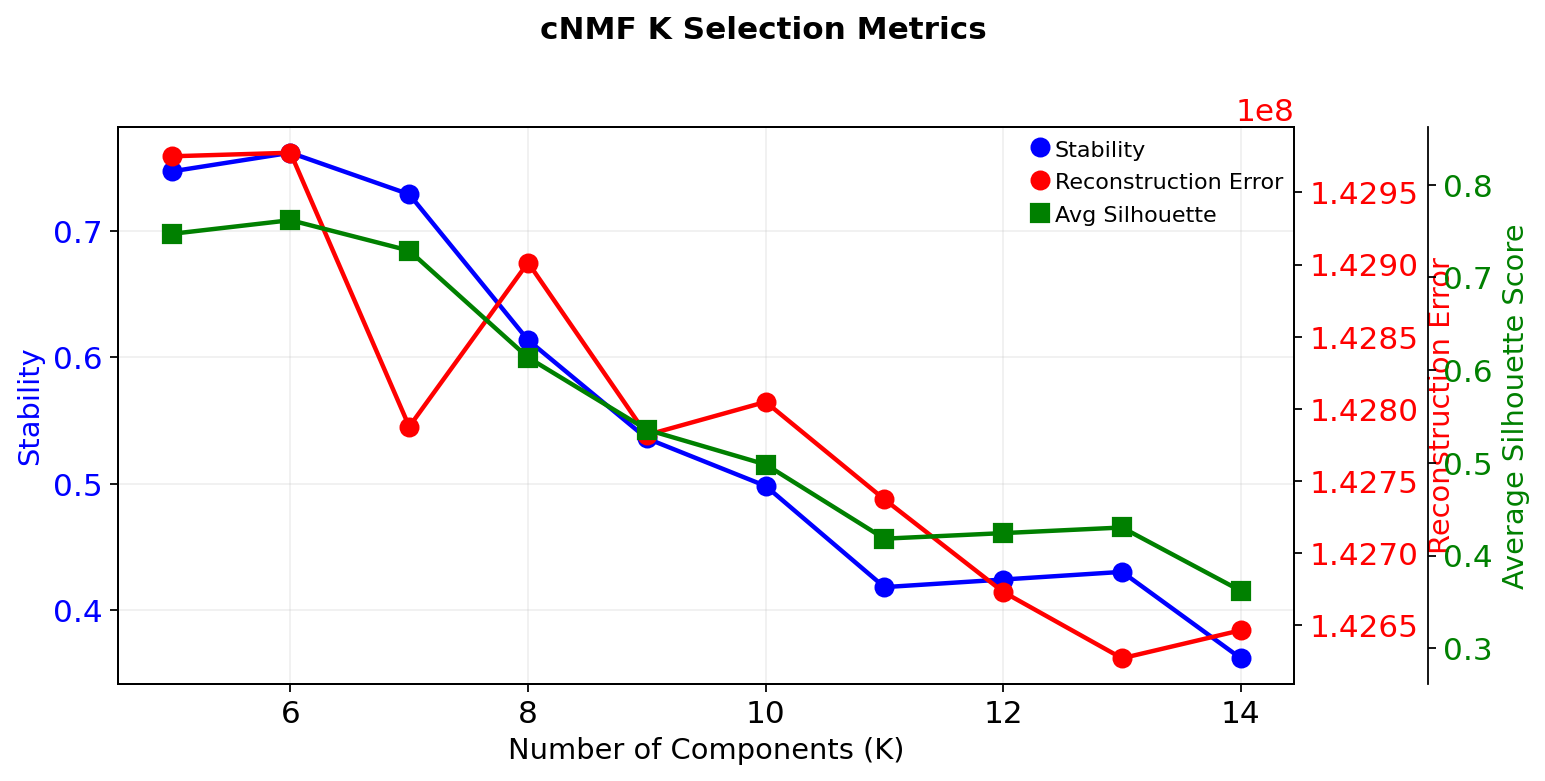

In [13]:
fig=cnmf_obj.k_selection_plot(close_fig=False)

In [15]:
selected_K = 7
density_threshold = 0.1
cnmf_obj.consensus(k=selected_K, 
                   density_threshold=density_threshold, 
                   show_clustering=False, 
                   close_clustergram_fig=False)

In [16]:
result_dict = cnmf_obj.load_results(K=selected_K, density_threshold=density_threshold)

In [17]:
cnmf_obj.save('cNMF/cnmf_obj.pkl')

✓ cNMF object saved to: cNMF/cnmf_obj.pkl
  - 200 factorization iterations
  - 10 merged spectra (K values)
  - 1 consensus results


Text(0.5, 1.0, 'Local density histogram')

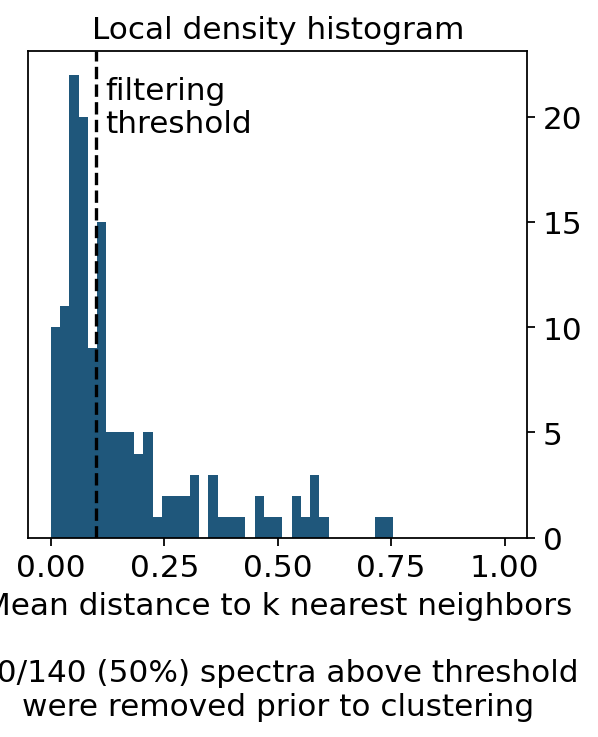

In [19]:
density_filter = cnmf_obj.local_density.iloc[:, 0] < density_threshold
fig, hist_ax = plt.subplots(figsize=(4,4))

#hist_ax = fig.add_subplot(hist_gs[0,0], xscale='linear', yscale='linear',
 #   xlabel='', ylabel='', frameon=True, title='Local density histogram')
hist_ax.hist(cnmf_obj.local_density.values, bins=np.linspace(0, 1, 50))
hist_ax.yaxis.tick_right()

xlim = hist_ax.get_xlim()
ylim = hist_ax.get_ylim()
if density_threshold < xlim[1]:
    hist_ax.axvline(density_threshold, linestyle='--', color='k')
    hist_ax.text(density_threshold  + 0.02, ylim[1] * 0.95, 'filtering\nthreshold\n\n', va='top')
hist_ax.set_xlim(xlim)
hist_ax.set_xlabel('Mean distance to k nearest neighbors\n\n%d/%d (%.0f%%) spectra above threshold\nwere removed prior to clustering'%(sum(~density_filter), len(density_filter), 100*(~density_filter).mean()))
hist_ax.set_title('Local density histogram')

In [20]:
cnmf_obj.get_results(adata_sub,result_dict)

cNMF_cluster is added to adata.obs
gene scores are added to adata.var


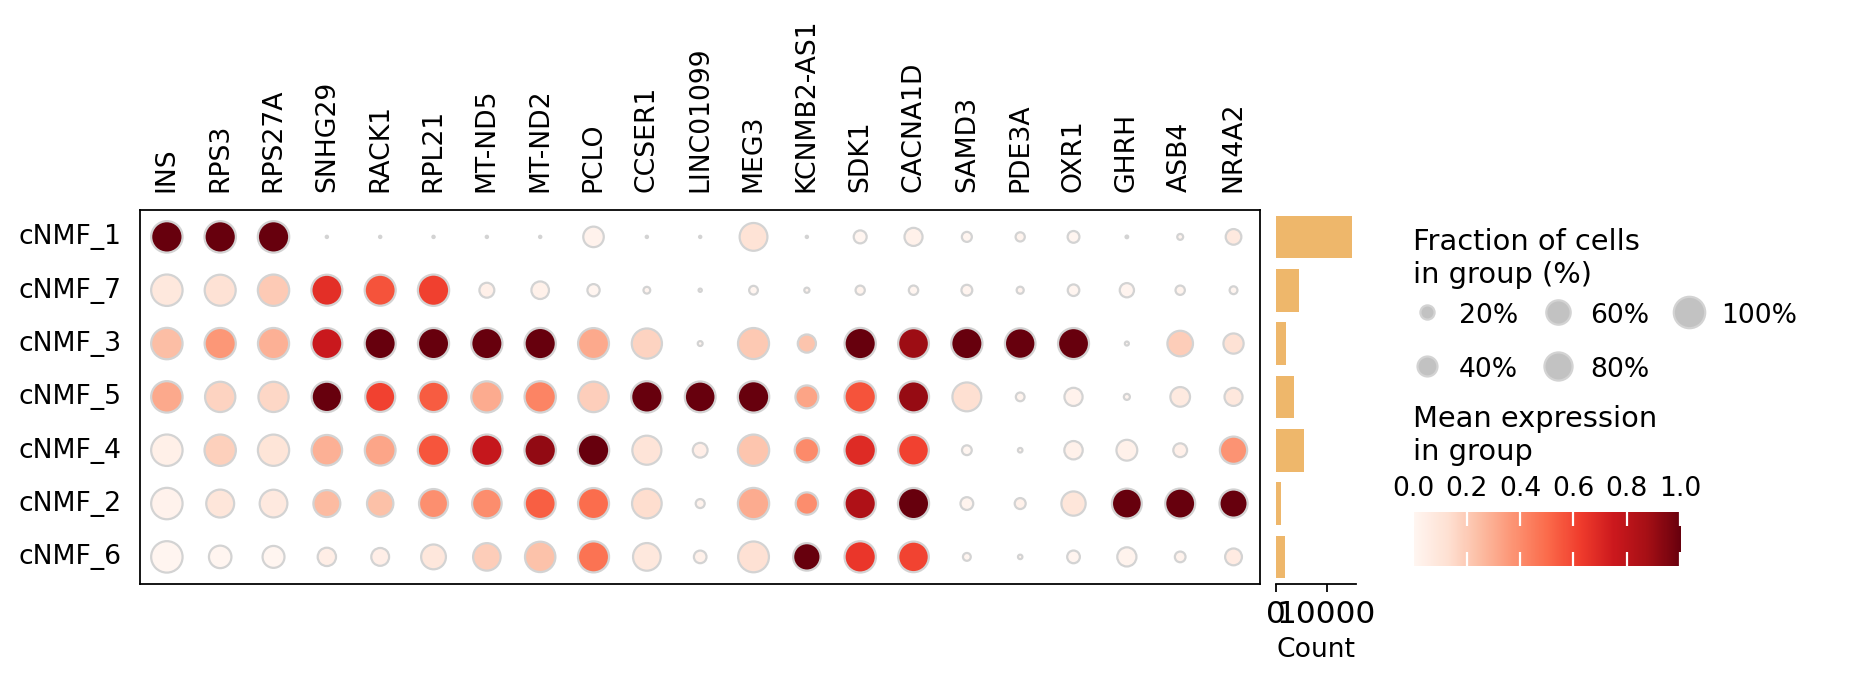

In [23]:
plot_genes=[]
for i in result_dict['top_genes'].columns:
    plot_genes+=result_dict['top_genes'][i][:3].values.reshape(-1).tolist()
ov.pl.dotplot(
    adata_sub,plot_genes,
    "cNMF_cluster", dendrogram=False,standard_scale='var',
)

In [26]:
adata_sub.obs.to_csv('cNMF/cNMF_obs_score.csv')

In [34]:
pd.DataFrame(result_dict['top_genes']).to_csv('cNMF/cNMF_top_genes.csv')